<a href="https://colab.research.google.com/github/MiguelR0462/Integracion_de_Datos_y_Prospectiva/blob/main/Reto_3_Integracion_Multidimensional.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Caso de Estudio: Integración Multidimensional**

Miguel Robledo Mejia

Integración de Datos y Prospectiva de Riesgo

Universidad EAFIT

**Descripción del caso**

Una entidad del sector Fintech requiere reducir el número de sucursales en las cuales atiende a cada uno de sus solicitantes de crédito, para lo cual la entidad financiera quiere llevar a cabo un proceso de integración multidimensional de los datos a cinco sucursales. Se debe determinar para cada sucursal el número de clientes, los municipios de procedencia y el porcentaje de preaprobación o prenegación.

**Metodología**

Para la integración multidimensional se emplea el método K-Medoids, tomando como referencia un total de 5 semillas aleatorias correspondientes a los primeros cinco solicitantes de crédito del conjunto de datos. A diferencia de K-Means, K-Medoids utiliza observaciones reales como centroides, lo que lo hace más robusto frente a valores atípicos en las variables financieras. Los clústeres resultantes se representan mediante gráficos de araña, que permiten comparar el comportamiento multidimensional de cada grupo de forma simultánea.

**Variables**

- Edad: Número de años cumplidos del solicitante; indica su etapa de vida y puede influir en su perfil de riesgo crediticio.
- Hijos: Cantidad de hijos del solicitante; refleja responsabilidades familiares que pueden afectar su capacidad de pago.
- Personas a Cargo: Número de personas que dependen económicamente del solicitante, incluyendo hijos u otros dependientes.
- Estrato: Clasificación socioeconómica del hogar que indica el nivel de ingresos y condiciones de vida.
- Ingresos: Total de dinero que percibe el solicitante en un periodo determinado, generalmente mensual.
- Egresos: Total de gastos o salidas de dinero del solicitante en un periodo determinado.
- Monto: Valor total del crédito solicitado.
- Plazo: Tiempo acordado para el pago del crédito, usualmente expresado en meses.
- Cuota del Crédito: Valor que el solicitante debe pagar periódicamente para amortizar el crédito, incluyendo capital e intereses.

In [1]:
# 0. cargamos las librerias de trabajo
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
# 1. montamos el drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# 2. montamos el archivo de trabajo
path = '/content/drive/MyDrive/Universidad/Semestre 8/Integracion de Datos y Prospectiva de Riesgo/Archivos/4. SolicitantesCrédito(USD)_Municipios.xlsx'
XDB = pd.read_excel(path)
XDB.head()


,Cédula,Edad,Sexo,Estado civil,Hijos,Perscargo,Nivel Renta,Estrato,Nivel de estudios,Tipo de contrato,...,ConoCliente,Garantia,RespPat,MoraCome,PreApr,Prob.Default (PD),Score,LGD,Net_Income,Municipio
0,1,38,NR,Casado,1,0,0,3,Bachiller,Ninguno,...,Buenas Referencias,Sin Codeudor,Sin Patrimonio,Con Experiencia sin Mora,1,0.041659,582.478943,0.063702,-329.478667,Bello
1,2,51,NR,Separado,6,1,1,4,Técnico,Ninguno,...,Buenas Referencias,Sin Codeudor,Prop.sin Hipoteca,Con Experiencia sin Mora,1,0.234951,479.839966,0.465636,-78.446000,Itagüí
2,3,37,Mujer,Casado,2,0,0,3,Tecnólogo,Indefinido,...,Buenas Referencias,Con Codeudor(es),Sin Patrimonio,Con Experiencia sin Mora,0,0.170330,417.653107,0.290071,-111.745639,Sabaneta
3,4,29,NR,Separado,1,0,0,2,Tecnólogo,Ninguno,...,Buenas Referencias,Con Codeudor(es),Sin Patrimonio,Con Experiencia sin Mora,1,0.201659,316.791107,0.278389,-78.346889,Sabaneta
4,5,42,Mujer,Casado,3,4,4,2,Especializacion,Ninguno,...,Buenas Referencias,Con Codeudor(es),Sin Patrimonio,Con Experiencia sin Mora,1,0.140929,441.809570,0.203359,-56.624028,Sabaneta


In [23]:
# 3. Ofuscamos los datos y limpiamos el dataset
XDB = XDB.sample(frac=1, random_state=37).reset_index(drop=True)
XDB.dropna(inplace=True)

In [31]:
# 4. Seleccionamos solo las variables numericas para la integracion
variables = ['Edad',
             'Hijos',
             'Perscargo',
             'Estrato',
             'Ingresos',
             'Egresos',
             'Monto (EAD)',
             'Plazo',
             'Cuota (COP)']
# 5. Creamos el nuevo df solo con variables numericas
XDB_num = XDB[variables]
XDB_num.head()

# 6. Normalizamos los datos

# usamos standard scaler porque maneja mejor los outliers
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
XDB_scaled_array = scaler.fit_transform(XDB[variables])
XDB_scaled = pd.DataFrame(XDB_scaled_array, columns=variables)
XDB_scaled.head()

,Edad,Hijos,Perscargo,Estrato,Ingresos,Egresos,Monto (EAD),Plazo,Cuota (COP)
0,-0.739458,0.751192,-0.828842,0.087749,-0.654690,-0.825474,-0.160078,0.270507,-0.255025
1,1.059109,-0.871761,1.128746,0.087749,-0.316405,-0.300897,-0.345029,-2.325183,1.924053
2,1.631380,-0.060284,0.149952,0.087749,0.635274,0.023921,0.555727,0.270507,-0.033936
3,-0.821211,-0.060284,-0.828842,3.133088,3.356212,2.176742,3.589926,-0.673380,1.466449
4,-0.248940,1.562669,-0.828842,-0.927363,-0.831370,-0.505874,-0.994150,-0.673380,-0.488780


In [25]:
# 7. Sacamos las semillas de integracion
XC = XDB_scaled[0:5]

nc = np.zeros((len(XDB_scaled), 1))

# 8. Hacemos la integración
for k in range(len(XDB_scaled)):
    Xind = XDB_scaled[k,]  # Clasificamos al individuo k - XIND = INDIVIDUO

    # calculamos la distancia relativa al cuadrado contra cada centroide
    denominador = np.where(XC[:, ] == 0, 0.0001, XC[:, ])
    m1 = np.sum(((XC[:, ] - Xind) / denominador)**2, axis=1)

    nc[k] = np.argmin(m1)  # lo asiganmos al cluster mas cercano
    cluster = int(np.argmin(m1))

    # actualizamos el centroide con el promedio móvil
    XC[cluster, ] = (XC[cluster, ] + Xind) / 2

print('Forma de los centroides finales:', XC.shape)

Forma de los centroides finales: (5, 9)


In [26]:
# 9. determinamos los resultados de cada cluster

# construimos un df con los centroides finales
dfxc = pd.DataFrame(XC)
dfxc.columns = variables

ND = []   #Número de datos por cluster
PA = []   #Porcentaje de preaprobación por cluster
PN = []   #Porcentaje de prenegación por cluster

for j in range(5):
    filas = np.where(nc[:, ] == j)[0]  #Filas de las personas de un cluster
    nd = len(filas)

    # calculamos el % de preaprobación y prenegación
    n_preaprobados = len(np.where(XDB.iloc[filas]['PreApr'] == 1)[0])
    n_prenegados = len(np.where(XDB.iloc[filas]['PreApr'] == 0)[0])
    pct_preaprobacion = round((n_preaprobados / nd) * 100, 2)
    pct_prenegacion = round((n_prenegados / nd) * 100, 2)

    print(f'Cluster (Sucursal) {j}')
    print(f'Número de clientes: {nd}')
    print(f'Preaprobados: {n_preaprobados} ({pct_preaprobacion}%)')
    print(f'Prenegados: {n_prenegados} ({pct_prenegacion}%)')

    #Se muestran los municipios de procedencia
    municipios = XDB.iloc[filas]['Municipio'].value_counts()
    print(f'Municipios de procedencia:')
    for mun, count in municipios.items():
        print(f'  {mun}: {count} solicitantes')
    print()

    ND.append(nd)
    PA.append(pct_preaprobacion)
    PN.append(pct_prenegacion)

dfxc['NDatos'] = ND
dfxc['% PreAprobación'] = PA
dfxc['% PreNegación'] = PN

Cluster (Sucursal) 0
Número de clientes: 472
Preaprobados: 217 (45.97%)
Prenegados: 255 (54.03%)
Municipios de procedencia:
  Sabaneta: 153 solicitantes
  Caldas: 146 solicitantes
  Bello: 84 solicitantes
  Itagüí: 53 solicitantes
  Medellín: 31 solicitantes
  Envigado: 5 solicitantes

Cluster (Sucursal) 1
Número de clientes: 1314
Preaprobados: 644 (49.01%)
Prenegados: 670 (50.99%)
Municipios de procedencia:
  Sabaneta: 435 solicitantes
  Caldas: 416 solicitantes
  Bello: 221 solicitantes
  Itagüí: 119 solicitantes
  Medellín: 110 solicitantes
  Envigado: 13 solicitantes

Cluster (Sucursal) 2
Número de clientes: 1030
Preaprobados: 506 (49.13%)
Prenegados: 524 (50.87%)
Municipios de procedencia:
  Caldas: 337 solicitantes
  Sabaneta: 302 solicitantes
  Bello: 208 solicitantes
  Itagüí: 97 solicitantes
  Medellín: 72 solicitantes
  Envigado: 14 solicitantes

Cluster (Sucursal) 3
Número de clientes: 1282
Preaprobados: 643 (50.16%)
Prenegados: 639 (49.84%)
Municipios de procedencia:
  Cald

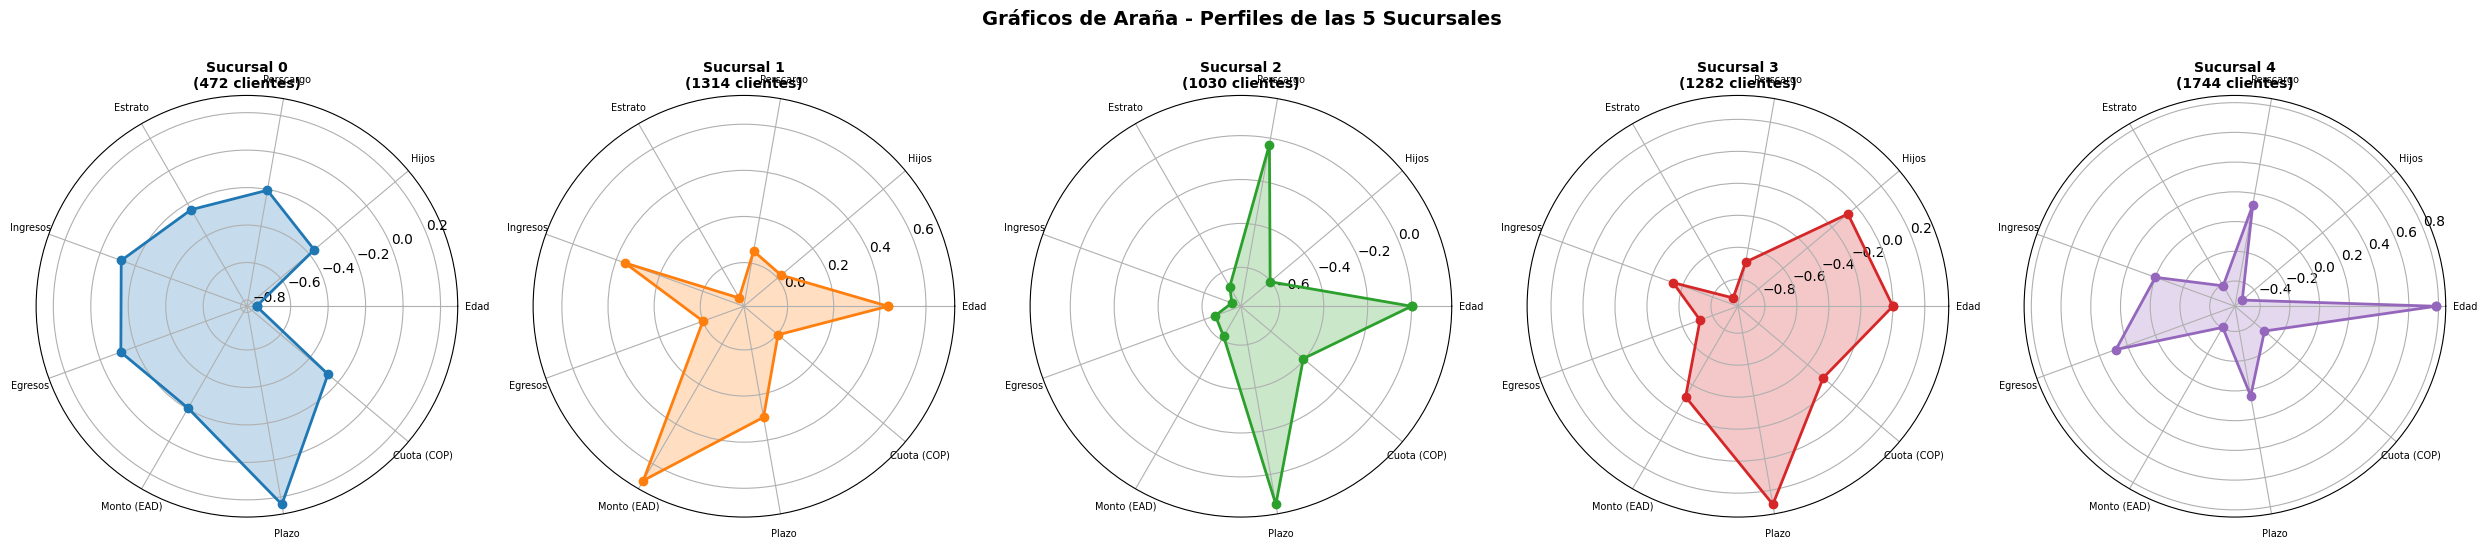

In [27]:
# 10. Hacemos la representacion de los clusters con graficos de araña

fig, axes = plt.subplots(1, 5, figsize=(25, 5), subplot_kw=dict(polar=True))
colores = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

for j in range(5):
    ax = axes[j]
    valores = dfxc[variables].iloc[j].values.tolist()
    valores += valores[:1]

    angulos = np.linspace(0, 2 * np.pi, len(variables), endpoint=False).tolist()
    angulos += angulos[:1]

    ax.plot(angulos, valores, 'o-', linewidth=2, color=colores[j])
    ax.fill(angulos, valores, alpha=0.25, color=colores[j])
    ax.set_xticks(angulos[:-1])
    ax.set_xticklabels(variables, fontsize=7)
    ax.set_title(f'Sucursal {j}\n({ND[j]} clientes)', fontsize=10, fontweight='bold')

plt.suptitle('Gráficos de Araña - Perfiles de las 5 Sucursales', fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig('radar_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

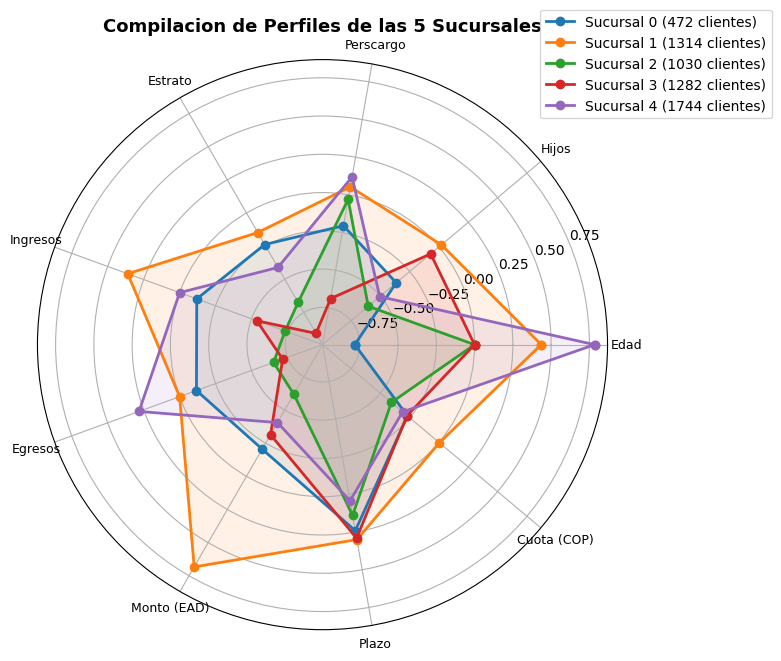

In [28]:
# 11. Compilamos todos los perfiles de las sucursales en un solo grafico de araña
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

angulos = np.linspace(0, 2 * np.pi, len(variables), endpoint=False).tolist()
angulos += angulos[:1]

for j in range(5):
    valores = dfxc[variables].iloc[j].values.tolist()
    valores += valores[:1]
    ax.plot(angulos, valores, 'o-', linewidth=2, color=colores[j], label=f'Sucursal {j} ({ND[j]} clientes)')
    ax.fill(angulos, valores, alpha=0.1, color=colores[j])

ax.set_xticks(angulos[:-1])
ax.set_xticklabels(variables, fontsize=9)
ax.set_title('Compilacion de Perfiles de las 5 Sucursales', fontsize=13, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.savefig('radar_consolidado.png', dpi=150, bbox_inches='tight')
plt.show()

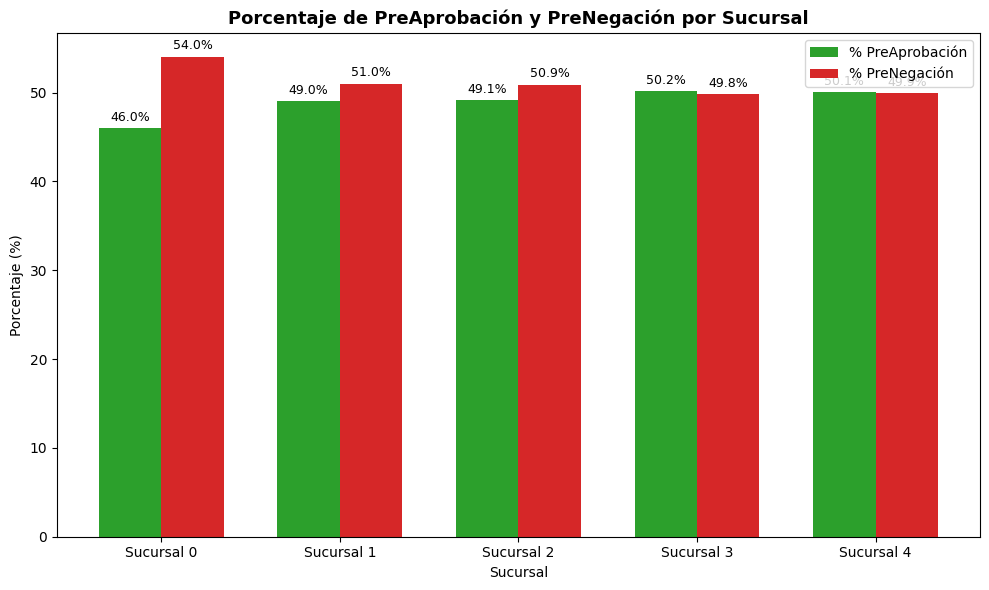

In [29]:
# 12. Revisamos el porcentaje de preaprobacion y prenegacion por sucursal
x = np.arange(5)
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, PA, width, label='% PreAprobación', color='#2ca02c')
bars2 = ax.bar(x + width/2, PN, width, label='% PreNegación', color='#d62728')

ax.set_xlabel('Sucursal')
ax.set_ylabel('Porcentaje (%)')
ax.set_title('Porcentaje de PreAprobación y PreNegación por Sucursal', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([f'Sucursal {j}' for j in range(5)])
ax.legend()

#agregamos las etiquetas de porcentaje
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('preaprobacion_por_sucursal.png', dpi=150, bbox_inches='tight')
plt.show()

## **Analisis de Resultados**

El proceso de integración multidimensional consolidó los 5.842 solicitantes en cinco sucursales con perfiles diferenciados. La Sucursal 4 tiene el mayor volumen de clientes con 1.744 registros, seguida de la Sucursal 1 con 1.314 y la Sucursal 3 con 1.282. La Sucursal 0 es la más pequeña, con 472 solicitantes, lo que sugiere que su perfil de centroide fue el más específico o restrictivo dentro del espacio multidimensional.
En cuanto a la preaprobación, la Sucursal 0 presenta el porcentaje más bajo con un 45.97%, siendo la única en la que la prenegación supera el 54%. Las Sucursales 3 y 4 son las únicas donde los preaprobados superan levemente a los prenegados, con 50.16% y 50.06% respectivamente. Las Sucursales 1 y 2 se mantienen en un rango intermedio, cercano al equilibrio. En términos generales, los porcentajes de preaprobación y prenegación son similares entre sucursales, lo que me muestra que el algoritmo no segmentó a los solicitantes por riesgo crediticio sino por características sociodemográficas y financieras.
Respecto a la procedencia geográfica, todos los clústeres reflejan de manera proporcional la distribución original del dataset: Caldas y Sabaneta dominan en cada sucursal, seguidos de Bello, Itagüí, Medellín y Envigado. Esto sugiere que la integración no tuvo un componente geográfico implícito, y que una eventual asignación de sucursales físicas debería complementarse con un criterio de cercania fisica, independiente del modelo.

## **Conclusión**

El modelo de integración multidimensional K-Medoids permitió consolidar los 5.842 solicitantes de crédito en cinco sucursales operativas, cumpliendo el objetivo de reducción planteado por la Fintech. Cada sucursal quedó caracterizada por un perfil diferenciado en las variables sociodemográficas y financieras, con tamaños que estan entre los 472 clientes de la Sucursal 0 y los 1.744 de la Sucursal 4, esta información es  útil para ver la capacidad operativa de cada punto de atención.
Sin embargo; dado que la distribución de municipios es  similar en todas las sucursales, la fintech debería complementar este analisis con un criterio de cercania geográfica para definir la ubicación física de cada una. Adicionalmente, el hecho de que ninguna sucursal tenga diferencias marcadas en su tasa de preaprobación sugiere que el riesgo crediticio está distribuido de manera homogénea entre los grupos, lo que es favorable desde una perspectiva de diversificación de cartera.